# Credit Card Fraud Detection using Clustering

## Part 1: Data Understanding

In [1]:
import pandas as pd

df = pd.read_csv("creditcard.csv.zip")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [2]:
print("Shape:", df.shape)
print("\nColumns:\n", df.columns)
print("\nMissing Values:\n", df.isnull().sum())

Shape: (284807, 31)

Columns:
 Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

Missing Values:
 Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


### Class Distribution

In [3]:
df['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

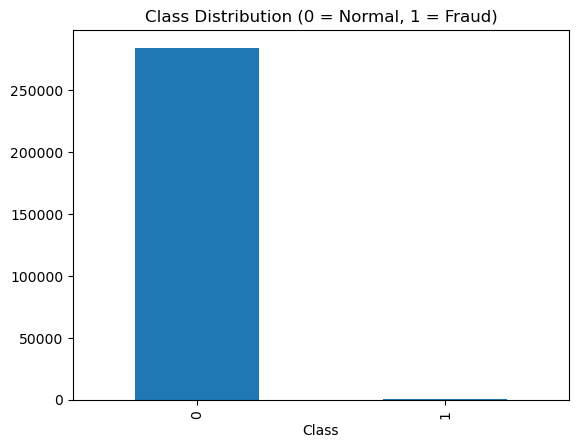

In [4]:
import matplotlib.pyplot as plt

df['Class'].value_counts().plot(kind='bar')
plt.title("Class Distribution (0 = Normal, 1 = Fraud)")
plt.show()

## Part 2: Data Preprocessing
### Feature Scaling

In [5]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Drop Class for training
X = df.drop('Class', axis=1)

X_scaled = scaler.fit_transform(X)

## Part 3: Clustering (K-Means)
### Elbow Method

C:\ProgramData\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\ProgramData\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\ProgramData\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\ProgramData\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^

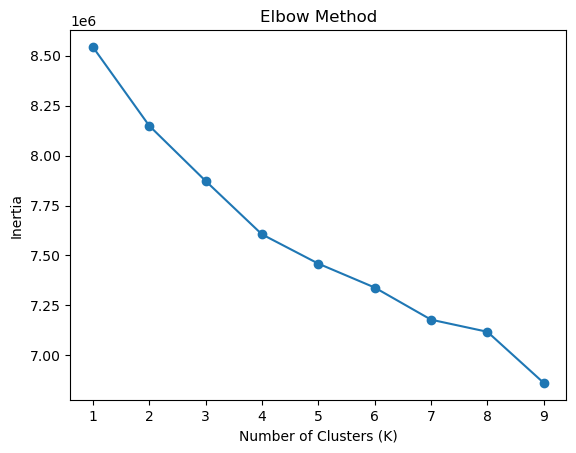

In [6]:
from sklearn.cluster import KMeans

inertia = []

for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 10), inertia, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

### Train Model

In [7]:
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans.fit(X_scaled)

labels = kmeans.labels_

## Part 4: Anomaly Detection
### Distance from Centroid

In [8]:
import numpy as np

# Distance to nearest centroid
distances = np.min(kmeans.transform(X_scaled), axis=1)

### Identify Top 1% Anomalies

In [9]:
threshold = np.percentile(distances, 99)

anomalies = distances > threshold

df['Anomaly'] = anomalies.astype(int)

## Part 5: Evaluation
### Confusion Matrix

In [10]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score

y_true = df['Class']
y_pred = df['Anomaly']

cm = confusion_matrix(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)

print("Confusion Matrix:\n", cm)
print("Precision:", precision)
print("Recall:", recall)

Confusion Matrix:
 [[281757   2558]
 [   201    291]]
Precision: 0.10214110214110214
Recall: 0.5914634146341463


## Part 6: Visualization (PCA)
### Reduce to 2D

In [11]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

### Plot Clusters

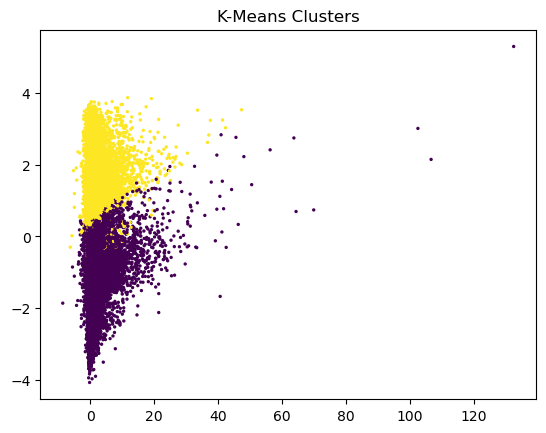

In [12]:
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels, s=2)
plt.title("K-Means Clusters")
plt.show()

### Plot Anomalies

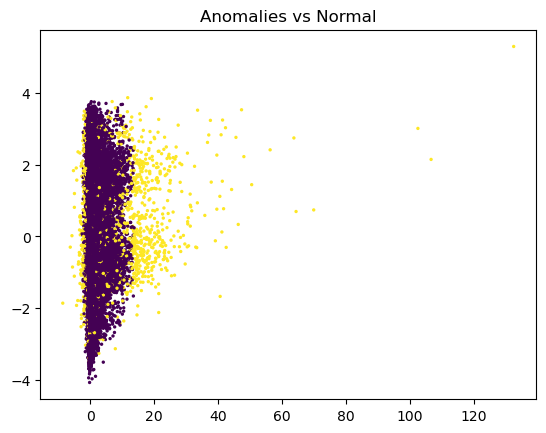

In [13]:
plt.scatter(X_pca[:,0], X_pca[:,1], c=df['Anomaly'], s=2)
plt.title("Anomalies vs Normal")
plt.show()

## Final Summary

- Used K-Means clustering to group transactions
- Calculated distance from centroid to detect anomalies
- Marked top 1% farthest points as fraud
- Evaluated using:
  Confusion Matrix
Precision
Recall
Visualized using PCA